In [1]:
import numpy as np
import pandas as pd
import xarray as xr

from experiments import utils
from package_name.evaluation import metrics
from package_name.training.trainer import VAEConfig
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling
import package_name.evaluation.s2s_eval_new as s2s_eval_new
from package_name.evaluation.pca_kmeans import  PCAKmeansPredictor, PCAKmeansTrainer


import matplotlib.pyplot as plt
plt.style.use('default')

%load_ext autoreload
%autoreload 2

In [2]:
#### CHANGE YOUR SETUP HERE ####
# SETUP = "iac_cluster"
SETUP = "quentin_mbp"

## Parameters and Config


In [3]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
if SETUP == "iac_cluster":
    results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/"
    pca_results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/PCA/"
    data_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/"
    z500_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/"
    s2s_path = "/net/helium/atmosdyn/vselvakumar/Data/C4E/Energy_var/s2s/"
elif SETUP == "quentin_mbp":
    results_path = "/Users/qnicolas/CodeForEarth/results/"
    pca_results_path = "/Users/qnicolas/CodeForEarth/results/PCA/"
    data_path = "/Users/qnicolas/CodeForEarth/data/wind/"
    z500_path = "/Users/qnicolas/CodeForEarth/data/"
    s2s_path = "/Users/qnicolas/CodeForEarth/data/s2s/"
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500

In [4]:
def load_vae(run_id, eval_region="europe"):
    """eval_region = europe or uk"""
    if eval_region == "europe":
        foldername = "training_test_split"
        pr_cluster_number = 4
        cluster_number = 4

    elif eval_region == "uk":
        foldername = "UK"
        pr_cluster_number = 8
        cluster_number = 8


    config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)


    vae = VAEPredictor(cfg=config)
    vae.load_weights(results_path + f"{foldername}/final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
    return vae

## Reanalysis data loading and pre-processing

In [5]:
# Get training data
z500 = utils.preprocess_dataset(filename = z500_path + "era5_z500_daily_250_atlantic_1940_2022.nc",
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = utils.GeographicalFilter.EXTENDED_EUROPE,
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
std_dev = z500.std()
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

## Hindcast Data loading


In [6]:
# Load s2s data
reference_dates_mmdd = [f"{month:02d}{day:02d}" for month in [1, 2] for day in [1, 8, 15, 22]]
members_datasets = [xr.open_dataset((f"{s2s_path}/plev_data_perturbed_members_2004{reference_date}-2020{reference_date}.grb"),engine="cfgrib") for reference_date in reference_dates_mmdd]
control_datasets = [xr.open_dataset((f"{s2s_path}/plev_data_unperturbed_control_member_2004{reference_date}-2020{reference_date}.grb"),engine="cfgrib") for reference_date in reference_dates_mmdd]

members_dataset = xr.concat(members_datasets, dim = 'time')
control_dataset = xr.concat(control_datasets, dim = 'time')
merged_dataset = xr.concat([members_dataset, control_dataset],dim="number")

z500_days_anom = utils.preprocess_forecast_data(
    dataset=merged_dataset,
    variable_name="gh",
    multiplication_factor=1.,
    geographical_filter=utils.GeographicalFilter.EXTENDED_EUROPE,
    anomalies=True,
    normalization=True,
    rolling_window=5,
    spatial_resolution=2.5,
    weights=weights
).gh


Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040101-20200101.grb.5b7b6.idx' incompatible with GRIB file


Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040108-20200108.grb.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040115-20200115.grb.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040122-20200122.grb.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040201-20200201.grb.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040208-20200208.grb.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040215-20200215.grb.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/Users/qnicolas/CodeForEarth/data/s2s//plev_data_perturbed_members_20040222-20200222.

# Target data loading

In [7]:
def load_target_data(eval_region = "europe"):
    if eval_region == "europe":
        prefix = "WON"
        pr_cluster_number = 4
    elif eval_region == "uk":
        prefix = "UK_8"
        pr_cluster_number = 8

    # Get training data labels
    target_labels = pd.read_csv(data_path + f'{prefix}_clusters_norm.csv')
    target_labels.columns = ['index', 'labels']

    target_labels['values']=[1]*len(target_labels)
    target_categorical_pd = pd.pivot_table(target_labels, values='values', index=['index'],
                        columns=['labels'], aggfunc=np.sum).fillna(0)
    target_categorical = target_categorical_pd.values
    target_categorical_xr = xr.DataArray(target_categorical, dims=['time', 'target'], coords={'time': z500.time, 'target': np.arange(pr_cluster_number)})
    return target_categorical, target_categorical_xr

# Score calculation

In [ ]:
def get_bss_vaes(target_categorical, target_categorical_xr, eval_region, cluster_number):
    """
    Get Brier Skill Scores (for all 10 trained CMM_VAEs) for the prediction of the target
    variable from hindcast data. Returns a matrix of shape (47, 10) where 47 is the 
    number of lead times and 10 is the number of trained CMM_VAEs.
    """
    bss_matrix = np.zeros((47,10))
    for run_id in range(10):
        # Load CMMVAE
        vae = load_vae(run_id=run_id, eval_region=eval_region)

        # 1. Calculate forecast of target variable from hindcast data
        cluster_probs = s2s_eval_new.forecast_target_variable_from_hindcast(
            z500_days_anom, z500, vae, target_categorical, cluster_number, model_type="vae"
        )

        # 2. Find matching target variable truth
        target_truth = s2s_eval_new.extract_matching_target_variable(
            z500_days_anom, target_categorical_xr
        )

        # 3. Derive baseline reference probabilities
        target_climatology = target_truth.mean(axis=(0,1))

        # 3. Run evaluation and plot
        bss = s2s_eval_new.compute_bootstrap_brier_skill_scores(
            cluster_probs, target_truth, target_climatology, n_bootstrap=1
        )

        bss_matrix[:,run_id] = bss[:,0]
    return bss_matrix

In [ ]:
def get_bss_pca(target_categorical, target_categorical_xr, cluster_number):
    """Retrain a PCA baseline model on the ERA5 training data and evaluate it on the 
    S2S hindcast data.
    Returns the BSS for the prediction of the target variable from hindcast data. 
    Returns a matrix of shape (47, 1) where 47 is the number of lead times.
    """
    X_train = z500_reshaped
    pca_kmeans_trainer = PCAKmeansTrainer(n_clusters=cluster_number, n_components=15, model_dir=pca_results_path)
    _, info = pca_kmeans_trainer.cluster(x=X_train)
    pca_kmeans_trainer.save_models(info)
    pca_kmeans_predictor = PCAKmeansPredictor(model_dir=pca_results_path)
    
    cluster_probs_pca = s2s_eval_new.forecast_target_variable_from_hindcast(
        z500_days_anom, z500, pca_kmeans_predictor, target_categorical, cluster_number, model_type="pca"
    )

    target_truth = s2s_eval_new.extract_matching_target_variable(
        z500_days_anom, target_categorical_xr
    )

    target_climatology = target_truth.mean(axis=(0,1))

    return s2s_eval_new.compute_bootstrap_brier_skill_scores(
        cluster_probs_pca, target_truth, target_climatology, n_bootstrap=1
    )

# European wind clusters BSS vs lead time

In [19]:
eval_region = "europe"; cluster_number=4
target_categorical, target_categorical_xr = load_target_data(eval_region=eval_region)
bss_vaes_europe = get_bss_vaes(target_categorical, target_categorical_xr, eval_region, cluster_number)
bss_pca_europe = get_bss_pca(target_categorical, target_categorical_xr, cluster_number)


2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 269us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 266us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 322us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 268us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 279us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 261us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 256us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 256us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 277us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 281us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step


(-0.05, 0.2)

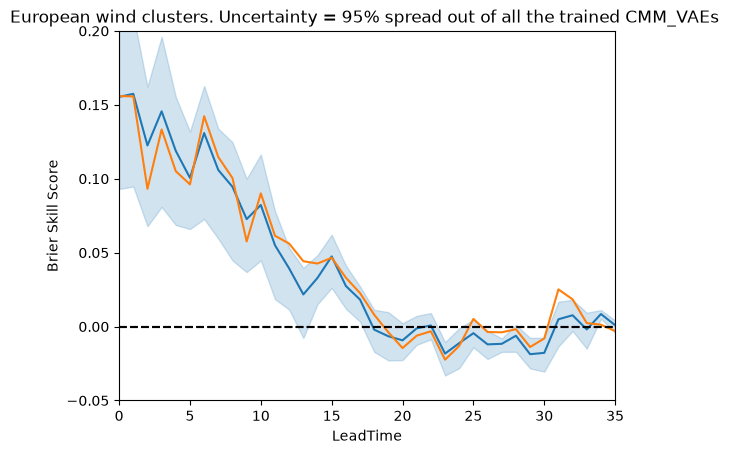

In [20]:
fig, ax = plt.subplots()

s2s_eval_new.plot_brier_skill_scores_bootstrap(ax, bss_vaes_europe)
s2s_eval_new.plot_brier_skill_score(ax, bss_pca_europe)

ax.set_title("European wind clusters. Uncertainty = 95% spread out of all the trained CMM_VAEs ")
ax.set_ylim(-.05,.2)

# UK wind clusters

In [21]:
eval_region = "uk"; cluster_number=8
target_categorical, target_categorical_xr = load_target_data(eval_region=eval_region)
bss_vaes_uk = get_bss_vaes(target_categorical, target_categorical_xr, eval_region, cluster_number)
bss_pca_uk = get_bss_pca(target_categorical, target_categorical_xr, cluster_number)


2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 296us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 308us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 307us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 261us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 256us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 258us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 319us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 264us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 262us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step


(-0.05, 0.2)

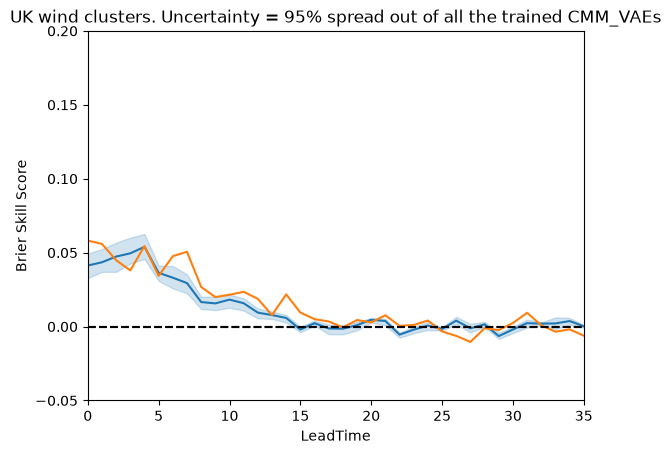

In [22]:
fig, ax = plt.subplots()

s2s_eval_new.plot_brier_skill_scores_bootstrap(ax, bss_vaes_uk)
s2s_eval_new.plot_brier_skill_score(ax, bss_pca_uk)

ax.set_title("UK wind clusters. Uncertainty = 95% spread out of all the trained CMM_VAEs")
ax.set_ylim(-.05,.2)

# UK low wind

In [23]:
eval_region = "uk"
target_categorical, target_categorical_xr = load_target_data(eval_region=eval_region)
# one-hot encoding of the first cluster vs all the others
target_categorical_lowwind = np.zeros((target_categorical.shape[0], 2))
target_categorical_lowwind[:,0] = target_categorical[:,0]
target_categorical_lowwind[:,1] = 1 - target_categorical[:,0]
target_categorical_lowwind_xr = xr.DataArray(target_categorical_lowwind, dims=['time', 'target'], coords={'time': z500.time, 'target': np.arange(2)})

bss_vaes_uk_lowwind = get_bss_vaes(target_categorical_lowwind, target_categorical_lowwind_xr, eval_region, cluster_number)
bss_pca_uk_lowwind = get_bss_pca(target_categorical_lowwind, target_categorical_lowwind_xr, cluster_number)


2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 303us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 260us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 255us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 254us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 255us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 289us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 271us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 275us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step
2198/2198 ━━━━━━━━━━━━━━━━━━━━ 1s 260us/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step


(-0.05, 0.2)

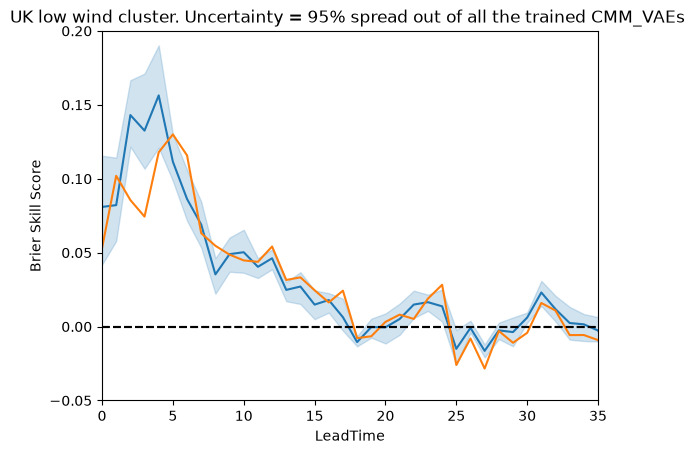

In [24]:
fig, ax = plt.subplots()

s2s_eval_new.plot_brier_skill_scores_bootstrap(ax, bss_vaes_uk_lowwind)
s2s_eval_new.plot_brier_skill_score(ax, bss_pca_uk_lowwind)

ax.set_title("UK low wind cluster. Uncertainty = 95% spread out of all the trained CMM_VAEs ")
ax.set_ylim(-.05,.2)